# Student Performance Prediction — Mathematics
## Bachelor Thesis | UCI Student Performance Dataset (Cortez & Silva, 2008)
**Dataset:** `../data/student-mat.csv`

**Pipeline:**
1. Data Loading & Preprocessing
2. Exploratory Data Analysis
3. Statistical Analysis
4. Machine Learning Models
5. Evaluation (ROC & Precision-Recall Curves)
6. SMOTE — Class Imbalance Mitigation


---
## Setup — Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

LABELS = {
    "age": "Age", "Medu": "Mother's Education", "Fedu": "Father's Education",
    "traveltime": "Travel Time to School", "studytime": "Weekly Study Time",
    "failures": "Past Class Failures", "famrel": "Family Relationship Quality",
    "freetime": "Free Time After School", "goout": "Going Out with Friends",
    "Dalc": "Workday Alcohol Consumption", "Walc": "Weekend Alcohol Consumption",
    "health": "Current Health Status", "absences": "Number of Absences",
    "G1": "First Period Grade", "G2": "Second Period Grade", "G3": "Final Grade (G3)",
    "paid_yes": "Paid Extra Classes", "schoolsup_yes": "Extra School Support",
    "famsup_yes": "Family Educational Support", "activities_yes": "Extracurricular Activities",
    "internet_yes": "Internet Access at Home", "romantic_yes": "In a Romantic Relationship",
    "higher_yes": "Wants Higher Education", "address_U": "Urban Home Address",
    "sex_M": "Sex (Male)", "school_MS": "School (Mousinho da Silveira)",
    "nursery_yes": "Attended Nursery School", "famsize_LE3": "Small Family Size",
    "Pstatus_T": "Parents Living Together",
    # Raw column names used in hypothesis tests
    "sex":        "Sex",
    "address":    "Home Address Type",
    "famsup":     "Family Educational Support",
    "paid":       "Paid Extra Classes",
    "internet":   "Internet Access at Home",
    "romantic":   "In a Romantic Relationship",
    "schoolsup":  "Extra School Support",
    "activities": "Extracurricular Activities",
    "higher":     "Wants Higher Education",
}
print("Setup complete.")

Setup complete.


---
## Phase 1 — Data Loading & Preprocessing

In [2]:
# Load raw dataset
df_raw = pd.read_csv("../data/student-mat.csv", sep=";")
print(f"Dataset shape: {df_raw.shape[0]} students x {df_raw.shape[1]} variables")
print()
print("First 5 rows:")
df_raw.head()

Dataset shape: 395 students x 33 variables

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
# Check for missing values
missing = df_raw.isnull().sum().sum()
print(f"Missing values: {'None found' if missing == 0 else missing}")

# Summary statistics for numeric columns
print()
df_raw.describe().round(2)

Missing values: None found


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


In [4]:
# Create binary pass/fail target — Portuguese passing threshold: 10/20
df_raw["pass_fail"] = (df_raw["G3"] >= 10).astype(int)

pass_n = df_raw["pass_fail"].sum()
fail_n = len(df_raw) - pass_n
print(f"Pass (G3 >= 10): {pass_n} students  ({pass_n/len(df_raw)*100:.1f}%)")
print(f"Fail (G3 <  10): {fail_n} students  ({fail_n/len(df_raw)*100:.1f}%)")
print(f"Naive baseline (always predict Pass): {pass_n/len(df_raw)*100:.1f}%")

Pass (G3 >= 10): 265 students  (67.1%)
Fail (G3 <  10): 130 students  (32.9%)
Naive baseline (always predict Pass): 67.1%


In [5]:
# One-hot encode categorical variables — drop_first avoids dummy variable trap
categorical_cols = df_raw.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns: {categorical_cols}")

df_encoded = pd.get_dummies(df_raw, columns=categorical_cols, drop_first=True)
print(f"\nShape before encoding: {df_raw.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")

# Define feature set — exclude G1, G2 (data leakage) and targets
exclude_cols = ["G3", "pass_fail", "G1", "G2"]
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
print(f"\nFeatures available: {len(feature_cols)}")
print("G1 and G2 EXCLUDED to prevent data leakage.")

X     = df_encoded[feature_cols]
y_reg = df_encoded["G3"]
y_clf = df_encoded["pass_fail"]

# Save preprocessed data
df_encoded.to_csv("../data/student_mat_preprocessed.csv", index=False)
print("Preprocessed dataset saved to ../data/student_preprocessed.csv")

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Shape before encoding: (395, 34)
Shape after encoding:  (395, 43)

Features available: 39
G1 and G2 EXCLUDED to prevent data leakage.
Preprocessed dataset saved to ../data/student_preprocessed.csv


---
## Phase 2 — Exploratory Data Analysis (EDA)

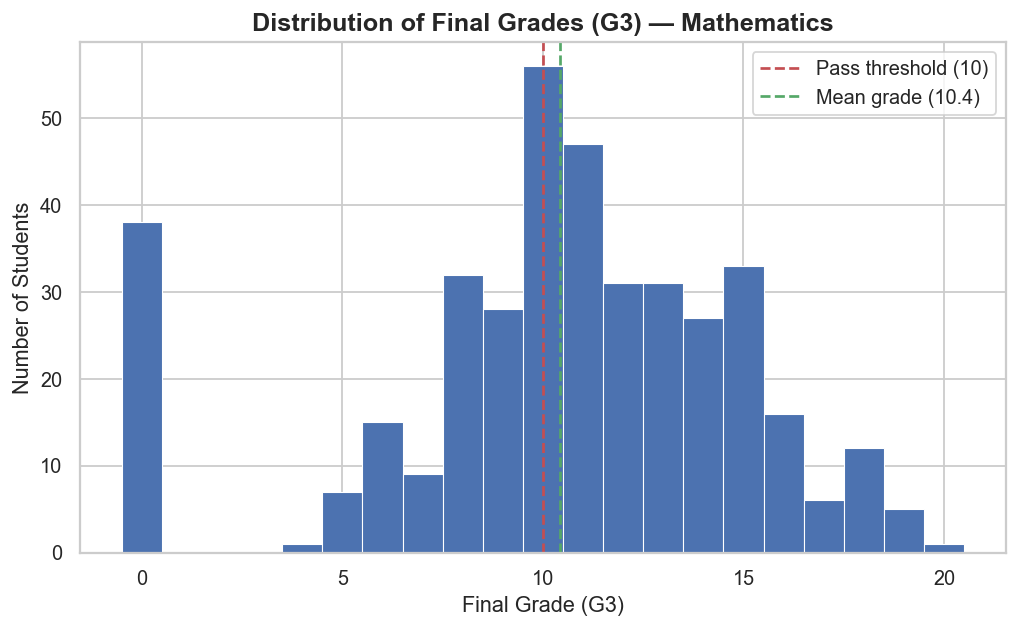

Mean: 10.42  |  Std: 4.58  |  Pass rate: 67.1%


In [6]:
# Plot 1: Grade Distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_raw["G3"], bins=21, range=(-0.5, 20.5),
        color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.axvline(x=10, color="#C44E52", linestyle="--", linewidth=1.5,
           label="Pass threshold (10)")
ax.axvline(x=df_raw["G3"].mean(), color="#55A868", linestyle="--", linewidth=1.5,
           label=f"Mean grade ({df_raw['G3'].mean():.1f})")
ax.set_title("Distribution of Final Grades (G3) — Mathematics",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Final Grade (G3)", fontsize=12)
ax.set_ylabel("Number of Students", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("../plots/mat_plot1_grade_distribution.png")
plt.show()
print(f"Mean: {df_raw['G3'].mean():.2f}  |  Std: {df_raw['G3'].std():.2f}  |  Pass rate: {df_raw['pass_fail'].mean()*100:.1f}%")

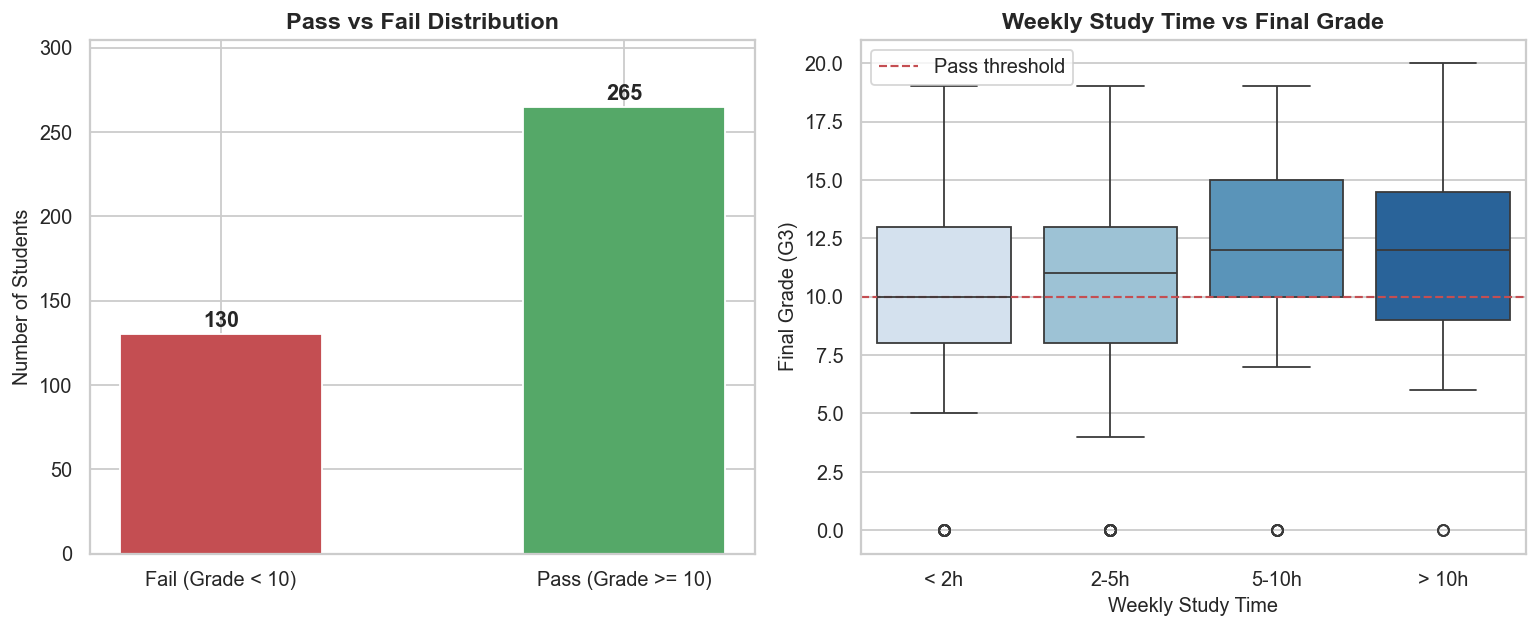

In [7]:
# Plot 2: Pass vs Fail | Study Time vs Grade
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pass/Fail bar chart
counts = df_raw["pass_fail"].value_counts().sort_index()
bars = axes[0].bar(["Fail (Grade < 10)", "Pass (Grade >= 10)"], counts.values,
                   color=["#C44E52", "#55A868"], edgecolor="white", width=0.5)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(count), ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[0].set_title("Pass vs Fail Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Students", fontsize=11)
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Study Time boxplot
studytime_labels = {1: "< 2h", 2: "2-5h", 3: "5-10h", 4: "> 10h"}
df_raw["studytime_label"] = df_raw["studytime"].map(studytime_labels)
order = ["< 2h", "2-5h", "5-10h", "> 10h"]
sns.boxplot(data=df_raw, x="studytime_label", y="G3", order=order,
            hue="studytime_label", hue_order=order,
            palette="Blues", legend=False, ax=axes[1])
axes[1].axhline(y=10, color="#C44E52", linestyle="--", linewidth=1.2,
                label="Pass threshold")
axes[1].set_title("Weekly Study Time vs Final Grade", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Weekly Study Time", fontsize=11)
axes[1].set_ylabel("Final Grade (G3)", fontsize=11)
axes[1].legend()
plt.tight_layout()
plt.savefig("../plots/mat_plot2_passfail_studytime.png")
plt.show()

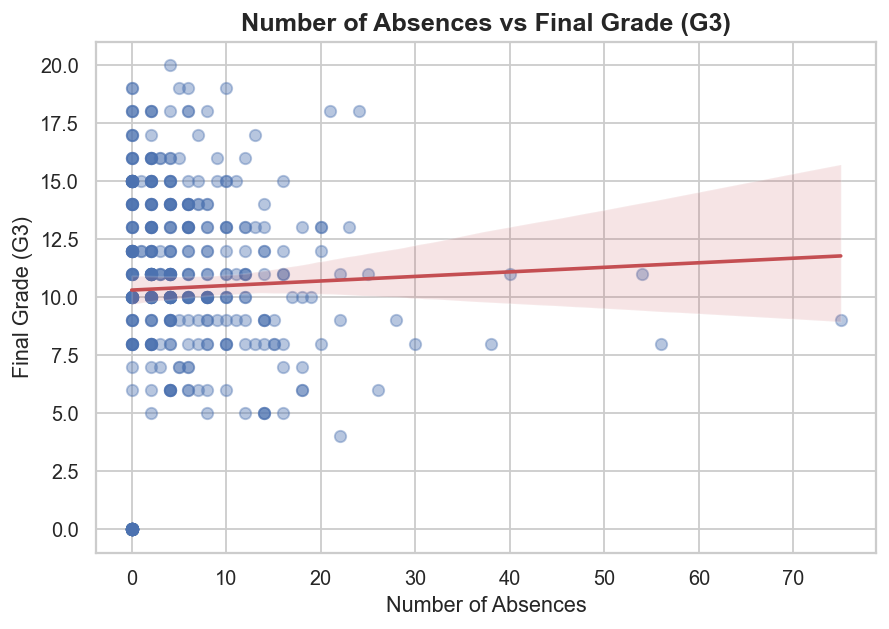

Pearson r (Absences vs G3): 0.0342  p = 0.4973
Note: near-zero linear correlation — but Random Forest will rank this #1 in importance!


In [8]:
# Plot 3: Absences vs Grade (scatter + regression line)
plt.rcdefaults()
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=df_raw, x="absences", y="G3",
            scatter_kws={"alpha": 0.4, "s": 40, "color": "#4C72B0"},
            line_kws={"color": "#C44E52", "linewidth": 2}, ax=ax)
ax.set_title("Number of Absences vs Final Grade (G3)", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Absences", fontsize=12)
ax.set_ylabel("Final Grade (G3)", fontsize=12)
plt.tight_layout()
plt.savefig("../plots/mat_plot4_absences_grade.png")
plt.show()

r_abs, p_abs = stats.pearsonr(df_raw["absences"], df_raw["G3"])
print(f"Pearson r (Absences vs G3): {r_abs:.4f}  p = {p_abs:.4f}")
print("Note: near-zero linear correlation — but Random Forest will rank this #1 in importance!")

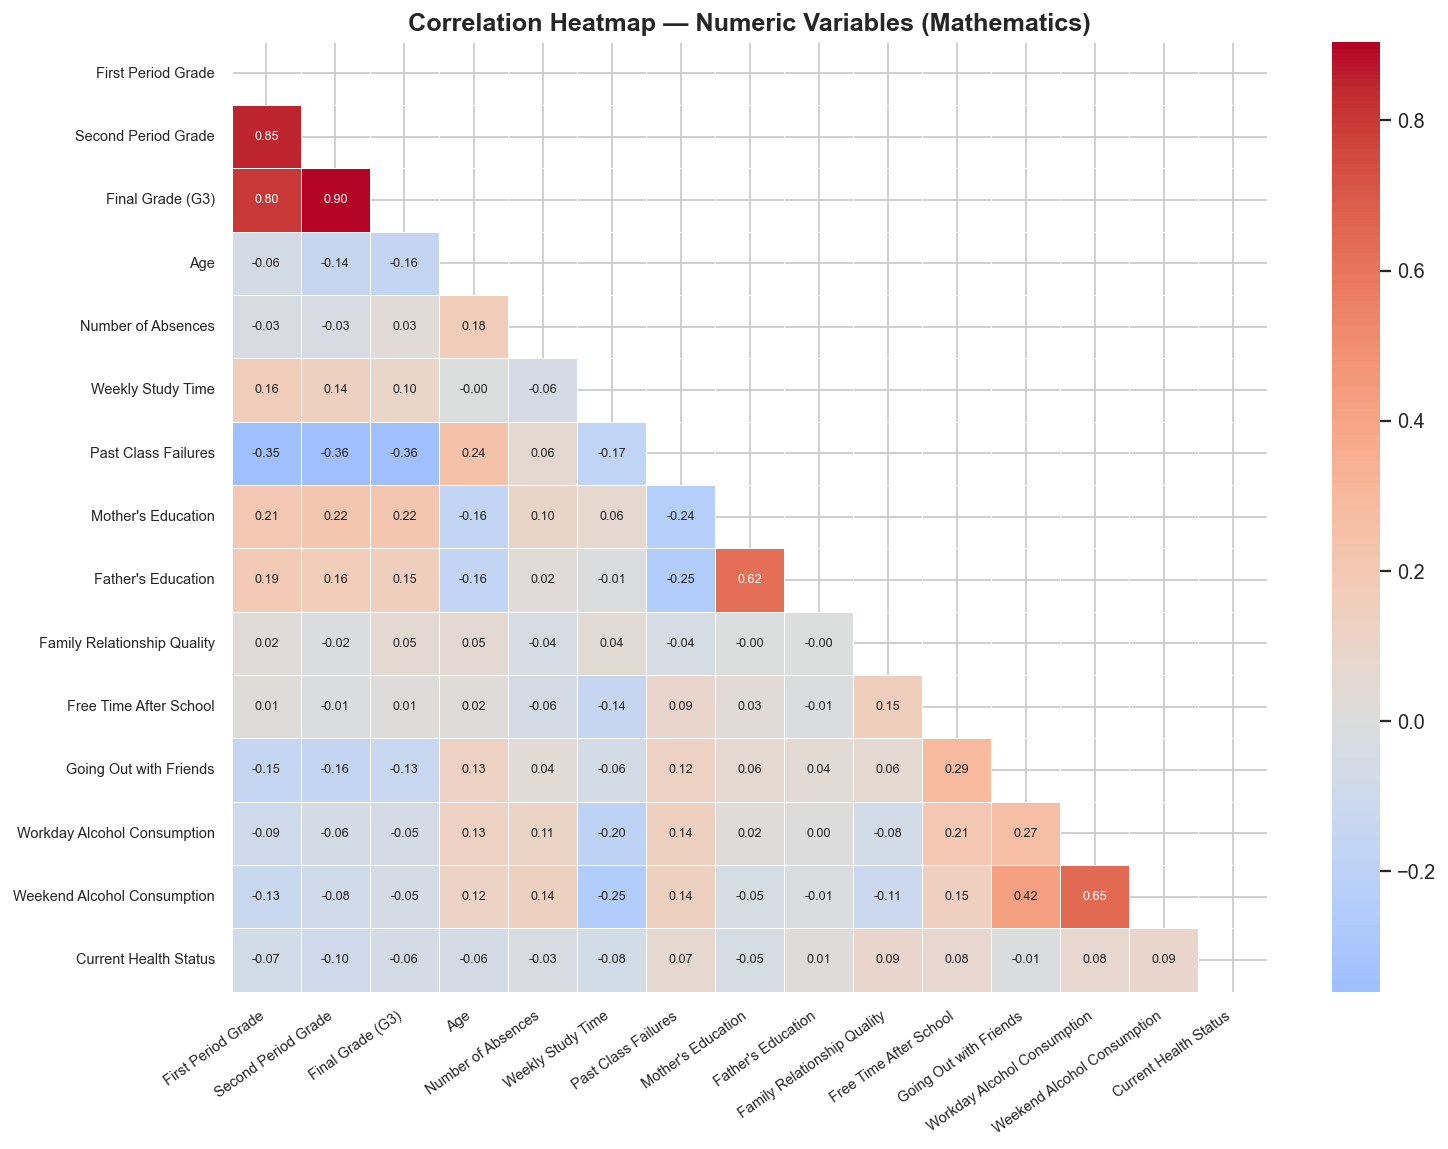

G1-G3 correlation: 0.80
G2-G3 correlation: 0.90
=> High correlations justify excluding G1 and G2 from the feature set.


In [9]:
# Plot 4: Correlation Heatmap
numeric_cols = ["G1", "G2", "G3", "age", "absences", "studytime",
                "failures", "Medu", "Fedu", "famrel", "freetime",
                "goout", "Dalc", "Walc", "health"]

df_heatmap = df_raw[numeric_cols].copy()
df_heatmap.rename(columns=LABELS, inplace=True)
corr_matrix = df_heatmap.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Variables (Mathematics)",
             fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("../plots/mat_plot5_correlation_heatmap.png")
plt.show()
print(f"G1-G3 correlation: {corr_matrix.loc['Final Grade (G3)', 'First Period Grade']:.2f}")
print(f"G2-G3 correlation: {corr_matrix.loc['Final Grade (G3)', 'Second Period Grade']:.2f}")
print("=> High correlations justify excluding G1 and G2 from the feature set.")

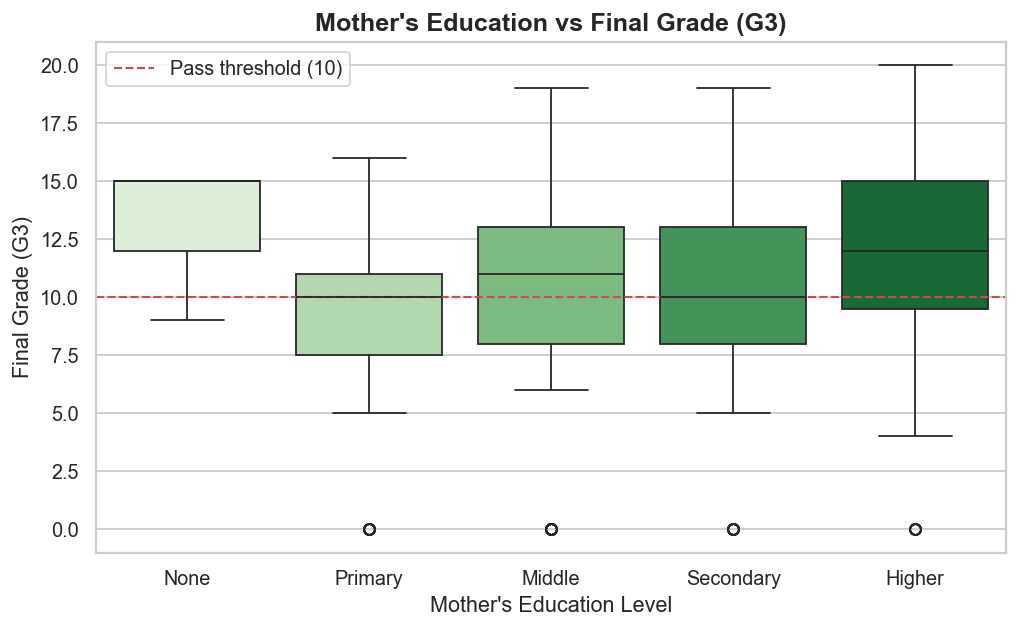

In [10]:
# Plot 5: Mother's Education vs Grade
medu_labels = {0: "None", 1: "Primary", 2: "Middle", 3: "Secondary", 4: "Higher"}
df_raw["Medu_label"] = df_raw["Medu"].map(medu_labels)
medu_order = ["None", "Primary", "Middle", "Secondary", "Higher"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_raw, x="Medu_label", y="G3",
            order=medu_order, hue="Medu_label", hue_order=medu_order,
            palette="Greens", legend=False, ax=ax)
ax.axhline(y=10, color="#C44E52", linestyle="--", linewidth=1.2,
           label="Pass threshold (10)")
ax.set_title("Mother's Education vs Final Grade (G3)", fontsize=14, fontweight="bold")
ax.set_xlabel("Mother's Education Level", fontsize=12)
ax.set_ylabel("Final Grade (G3)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("../plots/mat_plot6_medu_grade.png")
plt.show()

---
## Phase 3 — Statistical Analysis

In [11]:
# Shapiro-Wilk normality test
w_stat, p_norm = stats.shapiro(df_raw["G3"])
print(f"Shapiro-Wilk: W = {w_stat:.4f},  p = {p_norm:.6f}")
print(f"G3 is {'NOT ' if p_norm < 0.05 else ''}normally distributed (p < 0.05)" if p_norm < 0.05
      else "G3 appears normally distributed")
print("=> Justifies reporting Mann-Whitney U alongside t-test.")

Shapiro-Wilk: W = 0.9287,  p = 0.000000
G3 is NOT normally distributed (p < 0.05)
=> Justifies reporting Mann-Whitney U alongside t-test.


In [12]:
# Pearson Correlation Analysis — all numeric predictors vs G3
numeric_vars = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures",
                "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences"]

print(f"{'Variable':<30} {'r':>8} {'p-value':>12} {'Significant':>14} {'Strength':>12}")
print("-" * 65)

correlation_results = []
for var in numeric_vars:
    r, p = stats.pearsonr(df_raw[var], df_raw["G3"])
    sig = "Yes ***" if p < 0.001 else ("Yes **" if p < 0.01 else ("Yes *" if p < 0.05 else "No"))
    abs_r = abs(r)
    strength = "Strong" if abs_r >= 0.50 else ("Moderate" if abs_r >= 0.30 else
               ("Weak" if abs_r >= 0.10 else "Negligible"))
    direction = "positive" if r > 0 else "negative"
    label = LABELS.get(var, var)
    print(f"{label:<30} {r:>8.4f} {p:>12.4f} {sig:>14} {strength:>12}")
    correlation_results.append({
        "Variable": label, "r": round(r, 4), "p-value": round(p, 4),
        "Significant": "Yes" if p < 0.05 else "No",
        "Strength": strength, "Direction": direction
    })

corr_df = pd.DataFrame(correlation_results)
corr_df.to_csv("../results/mat_results_correlations.csv", index=False)
print("\nSaved: ../results/mat_results_correlations.csv")
print("\nSignificance: * p<0.05  ** p<0.01  *** p<0.001")

Variable                              r      p-value    Significant     Strength
-----------------------------------------------------------------
Age                             -0.1616       0.0013         Yes **         Weak
Mother's Education               0.2171       0.0000        Yes ***         Weak
Father's Education               0.1525       0.0024         Yes **         Weak
Travel Time to School           -0.1171       0.0199          Yes *         Weak
Weekly Study Time                0.0978       0.0521             No   Negligible
Past Class Failures             -0.3604       0.0000        Yes ***     Moderate
Family Relationship Quality      0.0514       0.3086             No   Negligible
Free Time After School           0.0113       0.8227             No   Negligible
Going Out with Friends          -0.1328       0.0082         Yes **         Weak
Workday Alcohol Consumption     -0.0547       0.2785             No   Negligible
Weekend Alcohol Consumption     -0.0519    

In [13]:
# Hypothesis Tests — binary variables vs G3
def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled if pooled != 0 else 0

def interpret_d(d):
    a = abs(d)
    return "Large" if a >= 0.80 else ("Medium" if a >= 0.50 else
           ("Small" if a >= 0.20 else "Negligible"))

binary_tests = [
    ("sex",        "F",   "M",   "Female",                 "Male"),
    ("address",    "U",   "R",   "Urban",                  "Rural"),
    ("famsup",     "yes", "no",  "Family support",         "No family support"),
    ("paid",       "yes", "no",  "Paid tutoring",          "No tutoring"),
    ("internet",   "yes", "no",  "Internet at home",       "No internet"),
    ("romantic",   "yes", "no",  "In a relationship",      "Not in relationship"),
    ("schoolsup",  "yes", "no",  "Extra school support",   "No school support"),
    ("activities", "yes", "no",  "Extracurricular",        "No activities"),
    ("higher",     "yes", "no",  "Wants higher edu.",      "Does not"),
]

hypothesis_results = []
for var, v1, v2, l1, l2 in binary_tests:
    g1 = df_raw[df_raw[var] == v1]["G3"]
    g2 = df_raw[df_raw[var] == v2]["G3"]
    _, t_p  = stats.ttest_ind(g1, g2)
    _, mw_p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    d       = cohens_d(g1, g2)
    print(f"{l1} vs {l2}:")
    print(f"  Mean G3: {g1.mean():.2f} vs {g2.mean():.2f}  |  "
          f"t p={t_p:.4f}  MW p={mw_p:.4f}  d={d:.3f} ({interpret_d(d)})  "
          f"{'SIG *' if t_p < 0.05 else ''}")
    hypothesis_results.append({
        "Variable": LABELS.get(var, var), "Group 1": l1, "Group 2": l2,
        "Mean G3 (Group 1)": round(g1.mean(),2), "Mean G3 (Group 2)": round(g2.mean(),2),
        "t p-value": round(t_p,4), "Mann-Whitney p": round(mw_p,4),
        "Cohen's d": round(d,3), "Effect Size": interpret_d(d),
        "Significant": "Yes" if t_p < 0.05 else "No"
    })

pd.DataFrame(hypothesis_results).to_csv("../results/mat_results_hypothesis_tests.csv", index=False)
print("\nSaved: ../results/mat_results_hypothesis_tests.csv")

Female vs Male:
  Mean G3: 9.97 vs 10.91  |  t p=0.0399  MW p=0.0407  d=-0.208 (Small)  SIG *
Urban vs Rural:
  Mean G3: 10.67 vs 9.51  |  t p=0.0356  MW p=0.0178  d=0.255 (Small)  SIG *
Family support vs No family support:
  Mean G3: 10.27 vs 10.64  |  t p=0.4377  MW p=0.3165  d=-0.080 (Negligible)  
Paid tutoring vs No tutoring:
  Mean G3: 10.92 vs 9.99  |  t p=0.0428  MW p=0.2267  d=0.205 (Small)  SIG *
Internet at home vs No internet:
  Mean G3: 10.62 vs 9.41  |  t p=0.0505  MW p=0.0324  d=0.265 (Small)  
In a relationship vs Not in relationship:
  Mean G3: 9.58 vs 10.84  |  t p=0.0097  MW p=0.0695  d=-0.277 (Small)  SIG *
Extra school support vs No school support:
  Mean G3: 9.43 vs 10.56  |  t p=0.1004  MW p=0.0028  d=-0.247 (Small)  
Extracurricular vs No activities:
  Mean G3: 10.49 vs 10.34  |  t p=0.7497  MW p=0.6049  d=0.032 (Negligible)  
Wants higher edu. vs Does not:
  Mean G3: 10.61 vs 6.80  |  t p=0.0003  MW p=0.0006  d=0.844 (Large)  SIG *

Saved: ../results/mat_result

---
## Phase 4 — Machine Learning Models

In [14]:
# Train/test split — 80/20, stratified, reproducible
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}  |  Test samples: {len(X_test)}")
print(f"Test — Pass: {(y_clf_test==1).sum()}  |  Fail: {(y_clf_test==0).sum()}")

# Feature scaling — fit on training only to prevent data leakage
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\nFeature scaling applied (Logistic Regression & Neural Network only).")
print("Random Forest uses unscaled features — tree-based, scale-invariant.")

Training samples: 316  |  Test samples: 79
Test — Pass: 52  |  Fail: 27

Feature scaling applied (Logistic Regression & Neural Network only).
Random Forest uses unscaled features — tree-based, scale-invariant.


MODEL 1: Linear Regression
  R2:             0.1415
  MAE:            3.3953  grade points average error
  RMSE:           4.1957
  CV R2 (5-fold): 0.0015 +/- 0.0958


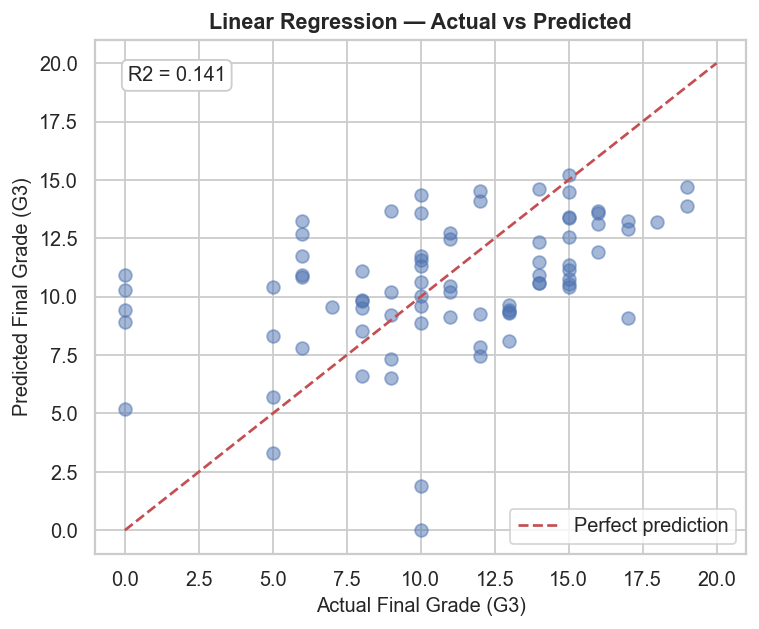

In [15]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_reg_train)
y_pred_lr = lr.predict(X_test)

r2   = r2_score(y_reg_test, y_pred_lr)
mae  = mean_absolute_error(y_reg_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr))
cv_r2 = cross_val_score(lr, X, y_reg, cv=5, scoring="r2")

print("MODEL 1: Linear Regression")
print(f"  R2:             {r2:.4f}")
print(f"  MAE:            {mae:.4f}  grade points average error")
print(f"  RMSE:           {rmse:.4f}")
print(f"  CV R2 (5-fold): {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_reg_test, y_pred_lr, alpha=0.5, color="#4C72B0", s=50)
ax.plot([0,20],[0,20], color="#C44E52", linewidth=1.5, linestyle="--",
        label="Perfect prediction")
ax.set_xlabel("Actual Final Grade (G3)", fontsize=11)
ax.set_ylabel("Predicted Final Grade (G3)", fontsize=11)
ax.set_title("Linear Regression — Actual vs Predicted", fontsize=12, fontweight="bold")
ax.text(0.05, 0.92, f"R2 = {r2:.3f}", transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc"))
ax.legend()
ax.set_xlim(-1,21); ax.set_ylim(-1,21)
plt.tight_layout()
plt.savefig("../plots/mat_plot7_linear_regression.png")
plt.show()

In [16]:
# Models 2-4: Classification
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf      = RandomForestClassifier(n_estimators=100, random_state=42)
nn      = MLPClassifier(hidden_layer_sizes=(32,), activation="relu",
                        max_iter=2000, early_stopping=True,
                        validation_fraction=0.1, n_iter_no_change=20,
                        random_state=42)

log_reg.fit(X_train_scaled, y_clf_train)
rf.fit(X_train, y_clf_train)
nn.fit(X_train_scaled, y_clf_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf  = rf.predict(X_test)
y_pred_nn  = nn.predict(X_test_scaled)

print(f"Neural Network converged in {nn.n_iter_} iterations.")
print()
print(f"Naive baseline (always predict Pass): {y_clf.mean()*100:.1f}%")
print()
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 62)
for name, yp in [("Logistic Regression", y_pred_log),
                  ("Random Forest",       y_pred_rf),
                  ("Neural Network",      y_pred_nn)]:
    acc  = accuracy_score(y_clf_test, yp)
    prec = precision_score(y_clf_test, yp, zero_division=0)
    rec  = recall_score(y_clf_test, yp, zero_division=0)
    f1   = f1_score(y_clf_test, yp, zero_division=0)
    print(f"{name:<22} {acc:>10.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}")

Neural Network converged in 50 iterations.

Naive baseline (always predict Pass): 67.1%

Model                    Accuracy  Precision   Recall       F1
--------------------------------------------------------------
Logistic Regression        0.7089     0.7377   0.8654   0.7965
Random Forest              0.6582     0.6812   0.9038   0.7769
Neural Network             0.6456     0.6818   0.8654   0.7627


In [17]:
# Classification Reports
for name, yp in [("Logistic Regression", y_pred_log),
                  ("Random Forest",       y_pred_rf),
                  ("Neural Network",      y_pred_nn)]:
    print(f"--- {name} ---")
    print(classification_report(y_clf_test, yp,
                                 target_names=["Fail", "Pass"], zero_division=0))

--- Logistic Regression ---
              precision    recall  f1-score   support

        Fail       0.61      0.41      0.49        27
        Pass       0.74      0.87      0.80        52

    accuracy                           0.71        79
   macro avg       0.67      0.64      0.64        79
weighted avg       0.69      0.71      0.69        79

--- Random Forest ---
              precision    recall  f1-score   support

        Fail       0.50      0.19      0.27        27
        Pass       0.68      0.90      0.78        52

    accuracy                           0.66        79
   macro avg       0.59      0.54      0.52        79
weighted avg       0.62      0.66      0.60        79

--- Neural Network ---
              precision    recall  f1-score   support

        Fail       0.46      0.22      0.30        27
        Pass       0.68      0.87      0.76        52

    accuracy                           0.65        79
   macro avg       0.57      0.54      0.53        79
w

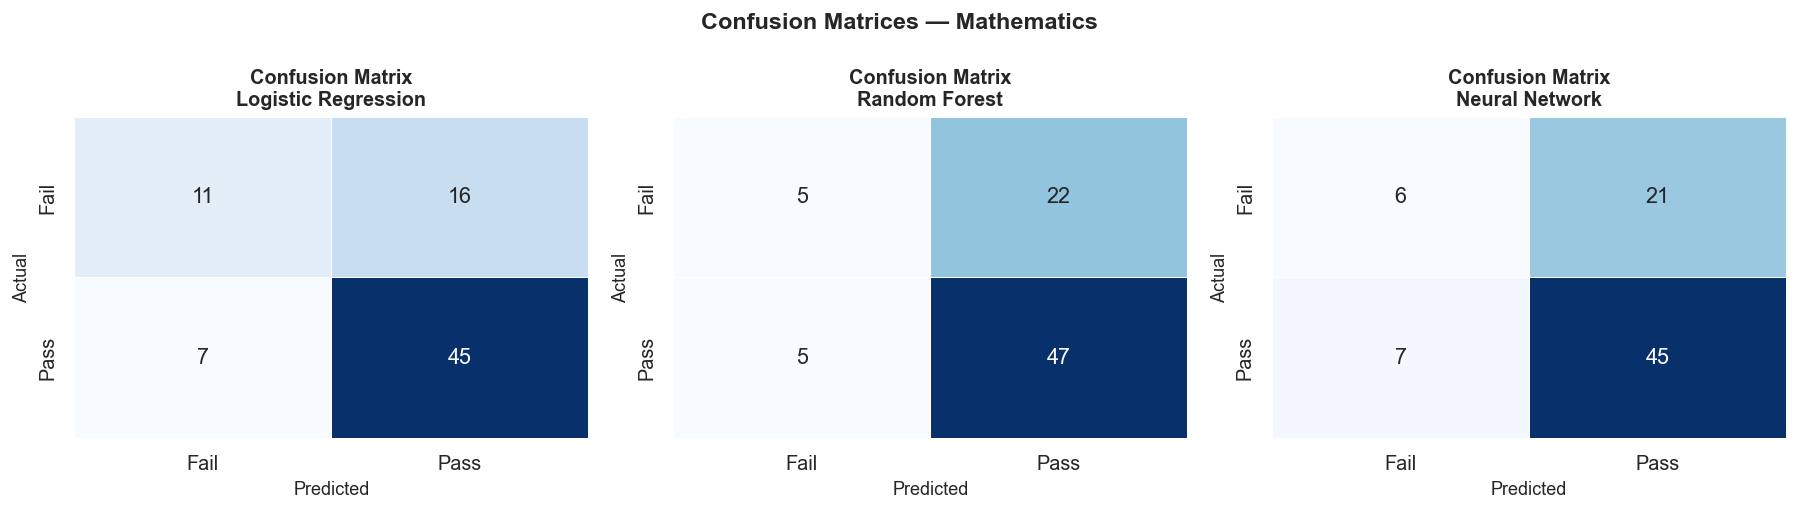

Total failing students in test set: 27
  Logistic Regression: caught 11/27 failing students  (Fail Recall = 0.4074)
  Random Forest: caught 5/27 failing students  (Fail Recall = 0.1852)
  Neural Network: caught 6/27 failing students  (Fail Recall = 0.2222)


In [18]:
# Confusion Matrices — all three classifiers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, y_pred, title in zip(
    axes,
    [y_pred_log, y_pred_rf, y_pred_nn],
    ["Logistic Regression", "Random Forest", "Neural Network"]
):
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fail","Pass"], yticklabels=["Fail","Pass"],
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix\n{title}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)
plt.suptitle("Confusion Matrices — Mathematics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/mat_plot8_confusion_matrices.png")
plt.show()

total_fail = (y_clf_test==0).sum()
print(f"Total failing students in test set: {total_fail}")
for name, yp in [("Logistic Regression", y_pred_log),
                  ("Random Forest",       y_pred_rf),
                  ("Neural Network",      y_pred_nn)]:
    cm = confusion_matrix(y_clf_test, yp)
    tn, fp, fn, tp = cm.ravel()
    fr = tn/(tn+fp) if (tn+fp)>0 else 0
    print(f"  {name}: caught {tn}/{total_fail} failing students  (Fail Recall = {fr:.4f})")

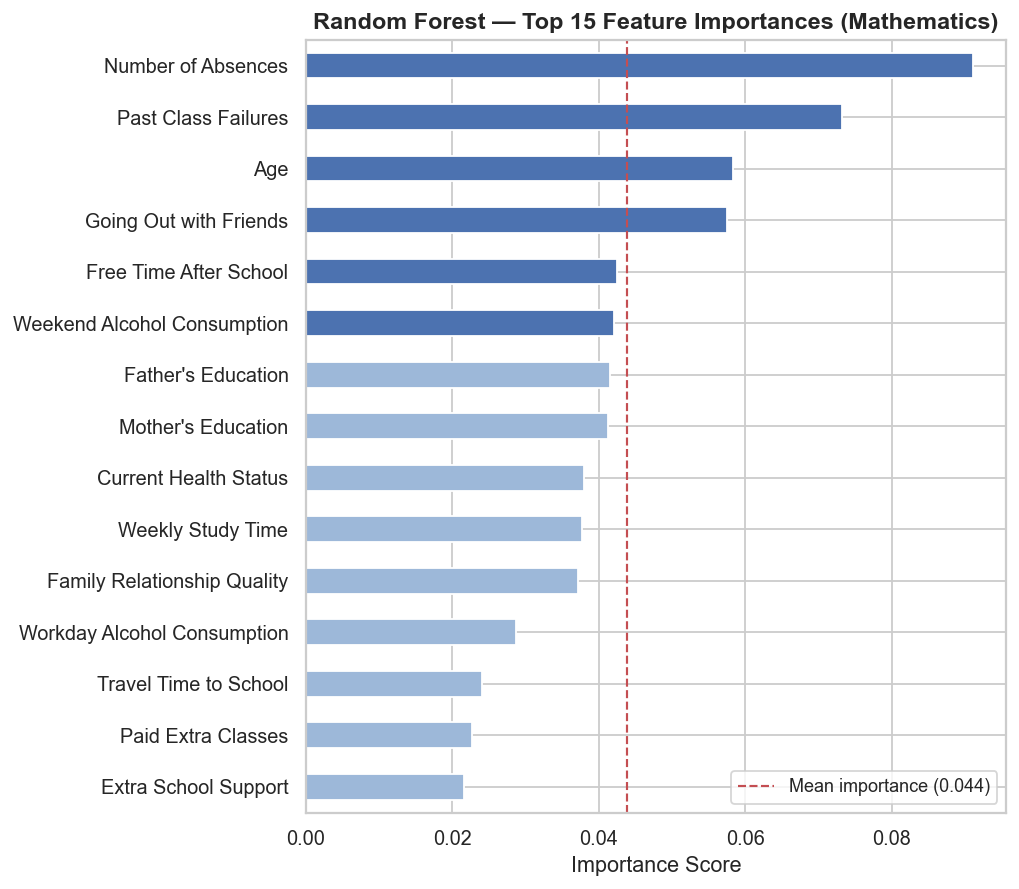

Top 5 features:
  1. Number of Absences: 0.0910
  2. Past Class Failures: 0.0732
  3. Age: 0.0584
  4. Going Out with Friends: 0.0575
  5. Free Time After School: 0.0425


In [19]:
# Feature Importances — Random Forest
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.index = [LABELS.get(col, col) for col in importances.index]
top15 = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#4C72B0" if v >= top15.quantile(0.6) else "#9DB8D9" for v in top15.values]
top15.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(x=top15.mean(), color="#C44E52", linestyle="--", linewidth=1.2,
           label=f"Mean importance ({top15.mean():.3f})")
ax.set_title("Random Forest — Top 15 Feature Importances (Mathematics)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../plots/mat_plot9_feature_importances.png")
plt.show()

print("Top 5 features:")
for i, (feat, score) in enumerate(importances.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")

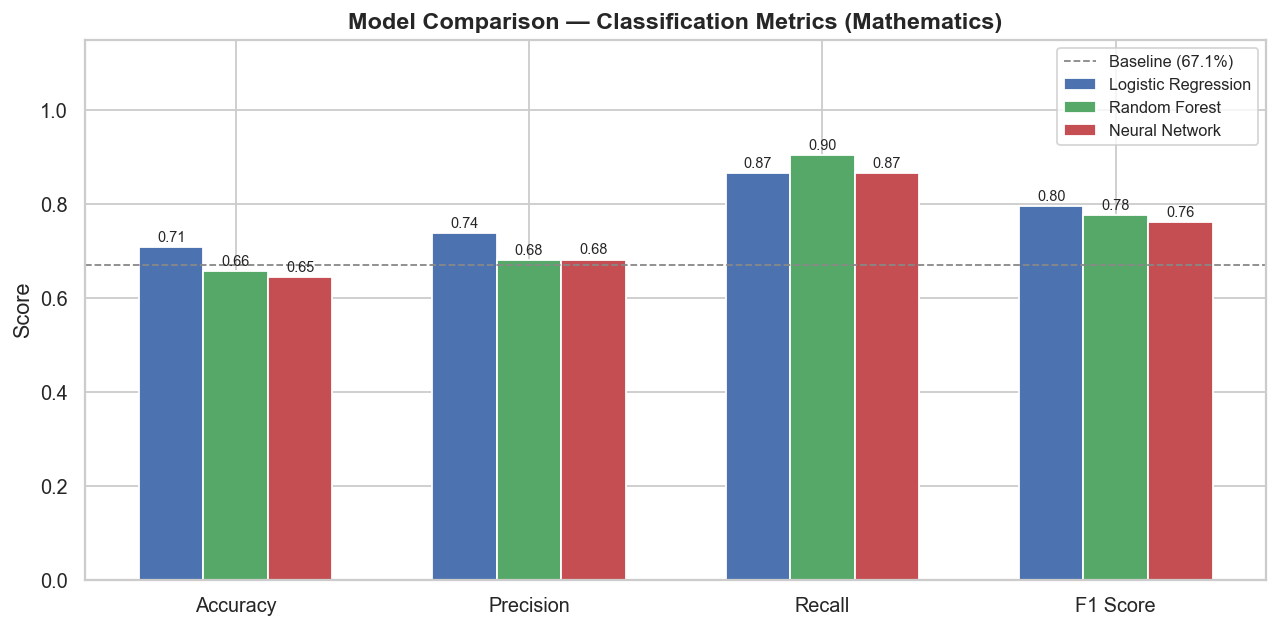

In [20]:
# Model Comparison Bar Chart
metrics_dict = {
    "Accuracy":  [accuracy_score(y_clf_test, y_pred_log),
                  accuracy_score(y_clf_test, y_pred_rf),
                  accuracy_score(y_clf_test, y_pred_nn)],
    "Precision": [precision_score(y_clf_test, y_pred_log, zero_division=0),
                  precision_score(y_clf_test, y_pred_rf, zero_division=0),
                  precision_score(y_clf_test, y_pred_nn, zero_division=0)],
    "Recall":    [recall_score(y_clf_test, y_pred_log, zero_division=0),
                  recall_score(y_clf_test, y_pred_rf, zero_division=0),
                  recall_score(y_clf_test, y_pred_nn, zero_division=0)],
    "F1 Score":  [f1_score(y_clf_test, y_pred_log, zero_division=0),
                  f1_score(y_clf_test, y_pred_rf, zero_division=0),
                  f1_score(y_clf_test, y_pred_nn, zero_division=0)],
}

x = np.arange(4); w = 0.22
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(metrics_dict.keys())
b1 = ax.bar(x-w,   [metrics_dict[m][0] for m in labels], w,
            label="Logistic Regression", color="#4C72B0", edgecolor="white")
b2 = ax.bar(x,     [metrics_dict[m][1] for m in labels], w,
            label="Random Forest",       color="#55A868", edgecolor="white")
b3 = ax.bar(x+w,   [metrics_dict[m][2] for m in labels], w,
            label="Neural Network",      color="#C44E52", edgecolor="white")
for bars in [b1,b2,b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(y=y_clf.mean(), color="#888", linestyle="--", linewidth=1,
           label=f"Baseline ({y_clf.mean()*100:.1f}%)")
ax.set_title("Model Comparison — Classification Metrics (Mathematics)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Score", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.15); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../plots/mat_plot10_model_comparison.png")
plt.show()

---
## Phase 5 — Evaluation: ROC & Precision-Recall Curves

In [21]:
# Full metrics table with cross-validation
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(lr, X, y_reg, cv=5, scoring="r2")
cv_log = cross_val_score(log_reg, X_train_scaled, y_clf_train, cv=skf, scoring="f1")
cv_rf  = cross_val_score(rf, X, y_clf, cv=skf, scoring="f1")
cv_nn  = cross_val_score(nn, X_train_scaled, y_clf_train, cv=skf, scoring="f1")

print(f"{'Metric':<28} {'Linear Reg':>12} {'Logistic Reg':>14} {'Random Forest':>14} {'Neural Net':>11}")
print("-" * 82)
print(f"{'R2':<28} {r2:>12.4f} {'--':>14} {'--':>14} {'--':>11}")
print(f"{'MAE':<28} {mae:>12.4f} {'--':>14} {'--':>14} {'--':>11}")
print(f"{'RMSE':<28} {rmse:>12.4f} {'--':>14} {'--':>14} {'--':>11}")

m_log = {"accuracy": accuracy_score(y_clf_test, y_pred_log),
         "f1": f1_score(y_clf_test, y_pred_log, zero_division=0)}
m_rf  = {"accuracy": accuracy_score(y_clf_test, y_pred_rf),
         "f1": f1_score(y_clf_test, y_pred_rf, zero_division=0)}
m_nn  = {"accuracy": accuracy_score(y_clf_test, y_pred_nn),
         "f1": f1_score(y_clf_test, y_pred_nn, zero_division=0)}

print(f"{'Accuracy':<28} {'--':>12} {m_log['accuracy']:>14.4f} {m_rf['accuracy']:>14.4f} {m_nn['accuracy']:>11.4f}")
print(f"{'F1 Score (Pass)':<28} {'--':>12} {m_log['f1']:>14.4f} {m_rf['f1']:>14.4f} {m_nn['f1']:>11.4f}")
print(f"{'CV Score (5-fold F1)':<28} {cv_r2.mean():>12.4f} {cv_log.mean():>14.4f} {cv_rf.mean():>14.4f} {cv_nn.mean():>11.4f}")
print(f"{'CV Std Dev':<28} {cv_r2.std():>12.4f} {cv_log.std():>14.4f} {cv_rf.std():>14.4f} {cv_nn.std():>11.4f}")

Metric                         Linear Reg   Logistic Reg  Random Forest  Neural Net
----------------------------------------------------------------------------------
R2                                 0.1415             --             --          --
MAE                                3.3953             --             --          --
RMSE                               4.1957             --             --          --
Accuracy                               --         0.7089         0.6582      0.6456
F1 Score (Pass)                        --         0.7965         0.7769      0.7627
CV Score (5-fold F1)               0.0015         0.7658         0.8072      0.7222
CV Std Dev                         0.0958         0.0466         0.0270      0.0842


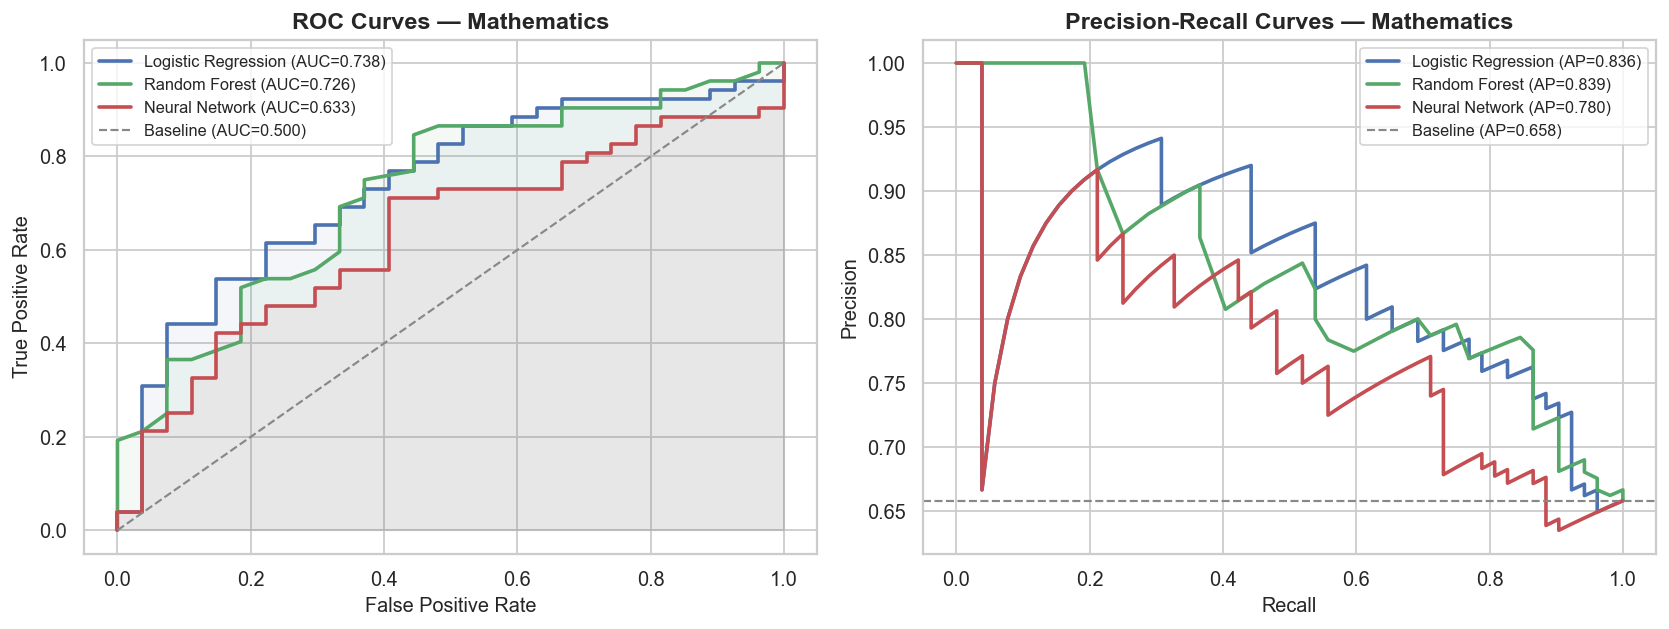

In [22]:
# Probability scores
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
y_prob_nn  = nn.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curves
ax = axes[0]
for prob, label, color in [
    (y_prob_log, "Logistic Regression", "#4C72B0"),
    (y_prob_rf,  "Random Forest",       "#55A868"),
    (y_prob_nn,  "Neural Network",      "#C44E52"),
]:
    fpr, tpr, _ = roc_curve(y_clf_test, prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{label} (AUC={auc_val:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)
ax.plot([0,1],[0,1], color="#888", linestyle="--", linewidth=1.2,
        label="Baseline (AUC=0.500)")
ax.set_title("ROC Curves — Mathematics", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(fontsize=9)

# Precision-Recall Curves
ax = axes[1]
baseline_pr = y_clf_test.mean()
for prob, label, color in [
    (y_prob_log, "Logistic Regression", "#4C72B0"),
    (y_prob_rf,  "Random Forest",       "#55A868"),
    (y_prob_nn,  "Neural Network",      "#C44E52"),
]:
    prec_c, rec_c, _ = precision_recall_curve(y_clf_test, prob)
    ap = average_precision_score(y_clf_test, prob)
    ax.plot(rec_c, prec_c, color=color, linewidth=2,
            label=f"{label} (AP={ap:.3f})")
ax.axhline(y=baseline_pr, color="#888", linestyle="--", linewidth=1.2,
           label=f"Baseline (AP={baseline_pr:.3f})")
ax.set_title("Precision-Recall Curves — Mathematics", fontsize=13, fontweight="bold")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../plots/mat_plot11_roc_pr_curves.png")
plt.show()

In [23]:
report = pd.DataFrame([
    {"Model": "Linear Regression",   "Task": "Regression",
     "R²": round(r2,4), "MAE": round(mae,4), "RMSE": round(rmse,4),
     "Accuracy": "--", "F1": "--",
     "CV Mean": round(cv_r2.mean(),4), "CV Std": round(cv_r2.std(),4), "AUC-ROC": "--"},
    {"Model": "Logistic Regression", "Task": "Classification",
     "R²": "--", "MAE": "--", "RMSE": "--",
     "Accuracy": round(m_log["accuracy"],4), "F1": round(m_log["f1"],4),
     "CV Mean": round(cv_log.mean(),4), "CV Std": round(cv_log.std(),4),
     "AUC-ROC": round(auc(roc_curve(y_clf_test,y_prob_log)[0],
                          roc_curve(y_clf_test,y_prob_log)[1]),4)},
    {"Model": "Random Forest",       "Task": "Classification",
     "R²": "--", "MAE": "--", "RMSE": "--",
     "Accuracy": round(m_rf["accuracy"],4), "F1": round(m_rf["f1"],4),
     "CV Mean": round(cv_rf.mean(),4), "CV Std": round(cv_rf.std(),4),
     "AUC-ROC": round(auc(roc_curve(y_clf_test,y_prob_rf)[0],
                          roc_curve(y_clf_test,y_prob_rf)[1]),4)},
    {"Model": "Neural Network",      "Task": "Classification",
     "R²": "--", "MAE": "--", "RMSE": "--",
     "Accuracy": round(m_nn["accuracy"],4), "F1": round(m_nn["f1"],4),
     "CV Mean": round(cv_nn.mean(),4), "CV Std": round(cv_nn.std(),4),
     "AUC-ROC": round(auc(roc_curve(y_clf_test,y_prob_nn)[0],
                          roc_curve(y_clf_test,y_prob_nn)[1]),4)},
])

---
## Phase 6 — SMOTE: Class Imbalance Mitigation

In [24]:
# Apply SMOTE to training set ONLY
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_clf_train)

print("Class distribution BEFORE SMOTE (training set):")
print(f"  Pass: {(y_clf_train==1).sum()}  ({(y_clf_train==1).mean()*100:.1f}%)")
print(f"  Fail: {(y_clf_train==0).sum()}  ({(y_clf_train==0).mean()*100:.1f}%)")
print()
print("Class distribution AFTER SMOTE (training set):")
print(f"  Pass: {(y_train_sm==1).sum()}  ({(y_train_sm==1).mean()*100:.1f}%)")
print(f"  Fail: {(y_train_sm==0).sum()}  ({(y_train_sm==0).mean()*100:.1f}%)")
print(f"  Total: {len(y_train_sm)} (was {len(y_clf_train)})")
print()
print("Test set UNCHANGED — reflects real-world class proportions.")

Class distribution BEFORE SMOTE (training set):
  Pass: 213  (67.4%)
  Fail: 103  (32.6%)

Class distribution AFTER SMOTE (training set):
  Pass: 213  (50.0%)
  Fail: 213  (50.0%)
  Total: 426 (was 316)

Test set UNCHANGED — reflects real-world class proportions.


In [25]:
# Train classifiers on SMOTE-balanced data
scaler_sm     = StandardScaler()
X_train_sm_sc = scaler_sm.fit_transform(X_train_sm)
X_test_sm_sc  = scaler_sm.transform(X_test)

lr_sm  = LogisticRegression(max_iter=1000, random_state=42)
rf_sm  = RandomForestClassifier(n_estimators=100, random_state=42)
nn_sm  = MLPClassifier(hidden_layer_sizes=(32,), activation="relu",
                       max_iter=2000, early_stopping=True,
                       validation_fraction=0.1, n_iter_no_change=20,
                       random_state=42)

lr_sm.fit(X_train_sm_sc, y_train_sm)
rf_sm.fit(X_train_sm, y_train_sm)
nn_sm.fit(X_train_sm_sc, y_train_sm)

y_pred_log_sm = lr_sm.predict(X_test_sm_sc)
y_pred_rf_sm  = rf_sm.predict(X_test)
y_pred_nn_sm  = nn_sm.predict(X_test_sm_sc)

def fail_recall(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

total_fail = (y_clf_test == 0).sum()
print(f"Failing students in test set: {total_fail}")
print()
print(f"{'Model':<22} {'Orig Fail Recall':>17} {'SMOTE Fail Recall':>18} {'Delta':>8}")
print("-" * 68)
for name, orig, sm in [
    ("Logistic Regression", y_pred_log, y_pred_log_sm),
    ("Random Forest",       y_pred_rf,  y_pred_rf_sm),
    ("Neural Network",      y_pred_nn,  y_pred_nn_sm),
]:
    fr_o = fail_recall(y_clf_test, orig)
    fr_s = fail_recall(y_clf_test, sm)
    d    = fr_s - fr_o
    sign = "+" if d >= 0 else ""
    print(f"{name:<22} {fr_o:>17.4f} {fr_s:>18.4f} {sign}{d:>7.4f}")

Failing students in test set: 27

Model                   Orig Fail Recall  SMOTE Fail Recall    Delta
--------------------------------------------------------------------
Logistic Regression               0.4074             0.5185 + 0.1111
Random Forest                     0.1852             0.3333 + 0.1481
Neural Network                    0.2222             0.3704 + 0.1481


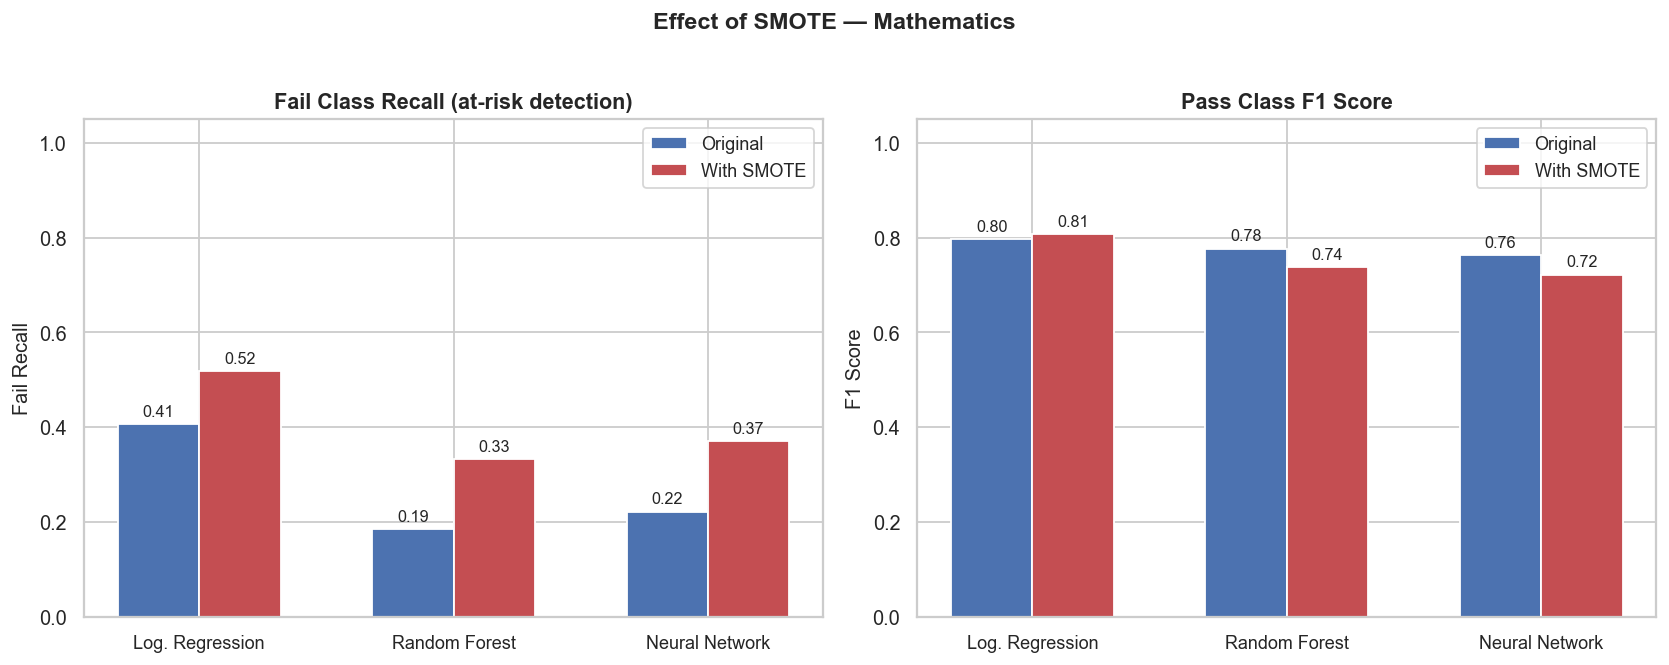

Saved: ../results/mat_results_smote.csv


In [26]:
# SMOTE comparison plots
model_names = ["Log. Regression", "Random Forest", "Neural Network"]
orig_preds  = [y_pred_log, y_pred_rf, y_pred_nn]
smote_preds = [y_pred_log_sm, y_pred_rf_sm, y_pred_nn_sm]

orig_fr  = [fail_recall(y_clf_test, p) for p in orig_preds]
smote_fr = [fail_recall(y_clf_test, p) for p in smote_preds]
orig_f1  = [f1_score(y_clf_test, p, zero_division=0) for p in orig_preds]
smote_f1 = [f1_score(y_clf_test, p, zero_division=0) for p in smote_preds]

x, w = np.arange(3), 0.32
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, orig_v, smote_v, title, ylabel in [
    (axes[0], orig_fr,  smote_fr,  "Fail Class Recall (at-risk detection)", "Fail Recall"),
    (axes[1], orig_f1,  smote_f1,  "Pass Class F1 Score",                   "F1 Score"),
]:
    b1 = ax.bar(x-w/2, orig_v,  w, label="Original",  color="#4C72B0", edgecolor="white")
    b2 = ax.bar(x+w/2, smote_v, w, label="With SMOTE", color="#C44E52", edgecolor="white")
    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylim(0, 1.05); ax.legend(fontsize=10)

plt.suptitle("Effect of SMOTE — Mathematics", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../plots/mat_plot_smote_comparison.png", bbox_inches="tight")
plt.show()

pd.DataFrame([
    {"Model": n, "Version": v,
     "Fail Recall": fail_recall(y_clf_test, p),
     "F1": f1_score(y_clf_test, p, zero_division=0),
     "Accuracy": accuracy_score(y_clf_test, p)}
    for n, orig, sm in zip(model_names, orig_preds, smote_preds)
    for v, p in [("Original", orig), ("SMOTE", sm)]
]).to_csv("../results/mat_results_smote.csv", index=False)
print("Saved: ../results/mat_results_smote.csv")

---
## Summary

In [27]:
print("=" * 60)
print("MATHEMATICS NOTEBOOK COMPLETE")
print("=" * 60)
print()
print("Files saved:")
print("  ../data/student_preprocessed.csv")
print("  ../results/mat_results_correlations.csv")
print("  ../results/mat_results_hypothesis_tests.csv")
print("  ../results/mat_results_final_report.csv")
print("  ../results/mat_results_smote.csv")
print("  ../plots/mat_plot1_grade_distribution.png")
print("  ../plots/mat_plot2_passfail_studytime.png")
print("  ../plots/mat_plot4_absences_grade.png")
print("  ../plots/mat_plot5_correlation_heatmap.png")
print("  ../plots/mat_plot6_medu_grade.png")
print("  ../plots/mat_plot7_linear_regression.png")
print("  ../plots/mat_plot8_confusion_matrices.png")
print("  ../plots/mat_plot9_feature_importances.png")
print("  ../plots/mat_plot10_model_comparison.png")
print("  ../plots/mat_plot11_roc_pr_curves.png")
print("  ../plots/mat_plot_smote_comparison.png")

MATHEMATICS NOTEBOOK COMPLETE

Files saved:
  ../data/student_preprocessed.csv
  ../results/mat_results_correlations.csv
  ../results/mat_results_hypothesis_tests.csv
  ../results/mat_results_final_report.csv
  ../results/mat_results_smote.csv
  ../plots/mat_plot1_grade_distribution.png
  ../plots/mat_plot2_passfail_studytime.png
  ../plots/mat_plot4_absences_grade.png
  ../plots/mat_plot5_correlation_heatmap.png
  ../plots/mat_plot6_medu_grade.png
  ../plots/mat_plot7_linear_regression.png
  ../plots/mat_plot8_confusion_matrices.png
  ../plots/mat_plot9_feature_importances.png
  ../plots/mat_plot10_model_comparison.png
  ../plots/mat_plot11_roc_pr_curves.png
  ../plots/mat_plot_smote_comparison.png
